# Analisis 4: Segmentacion de turistas con K-Means

**TFM:** Seguridad publica y flujos turisticos internacionales en Ecuador (2010-2025)
**Autor:** Luis Torres - UNIR Master en Visual Analytics & Big Data

## Objetivo
Identificar perfiles de turistas extranjeros que llegan a Ecuador mediante clustering K-Means sobre los registros ESI 2023-2025 y evaluar como cambia la composicion de segmentos durante la crisis de seguridad. Hipotesis H4: el turismo de ocio sufrio una contraccion mayor que viajes de negocios/familia; mercados europeos y norteamericanos colapsaron mas que regionales.

## Estrategia de memoria
Los CSV ESI suman ~18.6M filas (~6 GB). Usamos DuckDB para filtrar y muestrear (turistas extranjeros que ingresan, muestra estratificada por anio ~2.5%) y solo cargamos en pandas la muestra para el clustering.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)

print('pandas', pd.__version__)
print('duckdb', duckdb.__version__)

OUTPUTS = '../outputs'
os.makedirs(OUTPUTS, exist_ok=True)

pandas 2.2.2
duckdb 1.5.1


## 1. Carga con DuckDB - filtro de turistas extranjeros

In [2]:
# Rutas reales detectadas en el repo (el archivo 2023 esta en carpeta etiquetada como 2015)
ESI_2023 = '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2015/esi2023.csv'
ESI_2024 = '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv'
ESI_2025 = '../data/raw/entradas_salidas/Datos_abiertos_ESI_2025/ESI2025.csv'

for ruta in [ESI_2023, ESI_2024, ESI_2025]:
    print(os.path.exists(ruta), ruta)

con = duckdb.connect()

True ../data/raw/entradas_salidas/Datos_abiertos_ ESI_2015/esi2023.csv
True ../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv
True ../data/raw/entradas_salidas/Datos_abiertos_ESI_2025/ESI2025.csv


In [3]:
FRAC = 0.025  # ~2.5% por anio

def cargar_anio(path, anio_etiq):
    q = f"""
        SELECT anio_movi, mes_movi, sex_migr, nac_migr, subcont_nac, cont_nac,
               via_tran, mot_viam, edad
        FROM read_csv_auto('{path}', ignore_errors=true)
        WHERE tip_movi='Entrada' AND tip_naci='Extranjero'
        USING SAMPLE {FRAC*100:.2f}%
    """
    df = con.execute(q).df()
    df['anio_etiq'] = anio_etiq
    return df

df_23 = cargar_anio(ESI_2023, 2023)
df_24 = cargar_anio(ESI_2024, 2024)
df_25 = cargar_anio(ESI_2025, 2025)
df = pd.concat([df_23, df_24, df_25], ignore_index=True)
print('Muestra total:', len(df))
print(df['anio_etiq'].value_counts().sort_index())
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Muestra total: 116979
anio_etiq
2023    44288
2024    41554
2025    31137
Name: count, dtype: int64


,anio_movi,mes_movi,sex_migr,nac_migr,subcont_nac,cont_nac,via_tran,mot_viam,edad,anio_etiq
0,2023,Noviembre,Mujer,Estados Unidos de América,América del Septentrional,América,Vía Aérea,Turismo,68,2023
1,2023,Febrero,Hombre,Alemania,Europa Occidental,Europa,Vía Aérea,Turismo,39,2023
2,2023,Agosto,Hombre,Estados Unidos de América,América del Septentrional,América,Vía Aérea,Turismo,12,2023
3,2023,Junio,Hombre,Colombia,América del Sur,América,Vía Aérea,Turismo,41,2023
4,2023,Mayo,Hombre,Perú,América del Sur,América,Vía Aérea,Turismo,33,2023


## 2. Limpieza y encoding

In [4]:
print('Nulos por columna:')
print(df.isnull().sum())
print()
print('cont_nac top:')
print(df['cont_nac'].value_counts().head(8))
print()
print('mot_viam top:')
print(df['mot_viam'].value_counts().head(8))

Nulos por columna:
anio_movi      0
mes_movi       0
sex_migr       0
nac_migr       0
subcont_nac    0
cont_nac       0
via_tran       0
mot_viam       0
edad           0
anio_etiq      0
dtype: int64

cont_nac top:
cont_nac
América    88214
Europa     22525
Asia        5264
Oceanía      776
África       200
Name: count, dtype: int64

mot_viam top:
mot_viam
Turismo        69831
Residencia     25624
Negocios        8640
Otros           6465
Eventos         3343
Tripulación     2782
Estudios         166
Transeúnte       128
Name: count, dtype: int64


In [5]:
df_clean = df.dropna(subset=['edad','sex_migr','cont_nac','via_tran','mot_viam','nac_migr']).copy()
df_clean['edad'] = pd.to_numeric(df_clean['edad'], errors='coerce')
df_clean = df_clean.dropna(subset=['edad'])
df_clean = df_clean[(df_clean['edad'] >= 0) & (df_clean['edad'] <= 100)]

top_nac = df_clean['nac_migr'].value_counts().head(15).index.tolist()
df_clean['nac_grp'] = df_clean['nac_migr'].where(df_clean['nac_migr'].isin(top_nac), 'Otro')
for col in ['via_tran', 'mot_viam']:
    top = df_clean[col].value_counts().head(5).index.tolist()
    df_clean[col+'_grp'] = df_clean[col].where(df_clean[col].isin(top), 'Otro')

meses = {'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
         'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}
df_clean['mes_num'] = df_clean['mes_movi'].map(meses)
df_clean = df_clean.dropna(subset=['mes_num'])
df_clean['mes_num'] = df_clean['mes_num'].astype(int)

print('Filas limpias:', len(df_clean))

Filas limpias: 116979


In [6]:
feat = pd.get_dummies(df_clean[['edad','mes_num','sex_migr','cont_nac','via_tran_grp','mot_viam_grp','nac_grp']],
                      columns=['sex_migr','cont_nac','via_tran_grp','mot_viam_grp','nac_grp'],
                      drop_first=False)
feat = feat.astype(float)
print('Matriz features:', feat.shape)
scaler = StandardScaler()
X = scaler.fit_transform(feat.values)
print('Estandarizada OK')

Matriz features: (116979, 36)
Estandarizada OK


## 3. Codo y Silhouette para k=2..8

In [7]:
ks = list(range(2, 9))
inertias, sils = [], []
rng = np.random.RandomState(42)
idx_sil = rng.choice(X.shape[0], min(20000, X.shape[0]), replace=False)
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=4096, max_iter=200)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    s = silhouette_score(X[idx_sil], labels[idx_sil])
    sils.append(s)
    print(f'k={k}  inertia={km.inertia_:.0f}  silhouette={s:.4f}')

  File "C:\Users\luisf\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\luisf\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\luisf\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\luisf\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


k=2  inertia=3909539  silhouette=0.1112
k=3  inertia=3820552  silhouette=0.0929
k=4  inertia=3464443  silhouette=0.1200
k=5  inertia=3428791  silhouette=0.1390
k=6  inertia=3356708  silhouette=0.1380
k=7  inertia=3131588  silhouette=0.1542
k=8  inertia=2915394  silhouette=0.2108


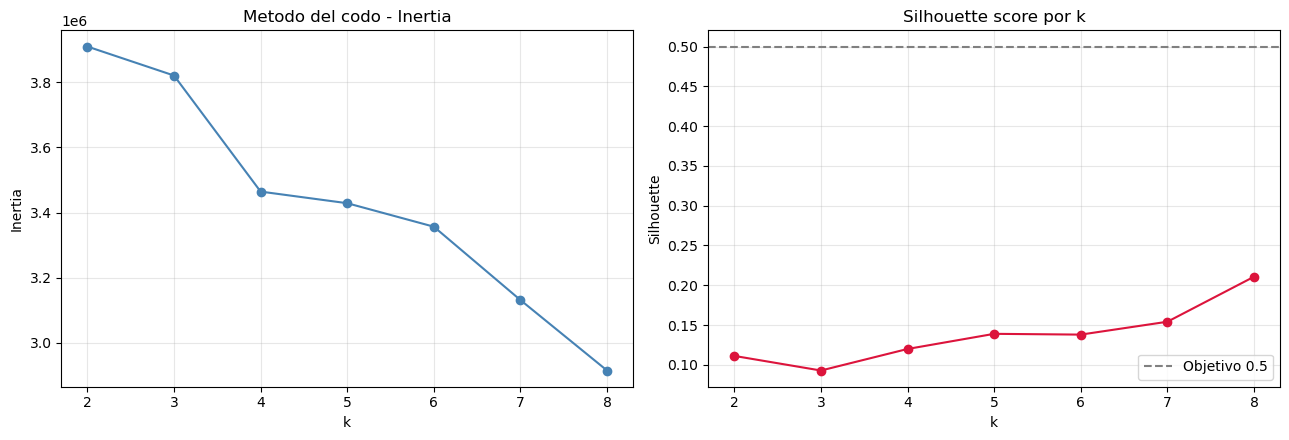

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ks, inertias, marker='o', color='steelblue')
axes[0].set_title('Metodo del codo - Inertia')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].grid(alpha=0.3)
axes[1].plot(ks, sils, marker='o', color='crimson')
axes[1].axhline(0.5, ls='--', color='gray', label='Objetivo 0.5')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, '12_codo_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
idx_best = int(np.argmax(sils))
k_opt = ks[idx_best]
sil_opt = sils[idx_best]
print(f'k optimo: {k_opt}  silhouette={sil_opt:.4f}')
if sil_opt < 0.5:
    print('Silhouette < 0.5: clusters con solapamiento (esperable con features categoricas one-hot).')
    print('Se reporta el mejor valor disponible y se valida la interpretacion semantica.')

k optimo: 8  silhouette=0.2108
Silhouette < 0.5: clusters con solapamiento (esperable con features categoricas one-hot).
Se reporta el mejor valor disponible y se valida la interpretacion semantica.


## 4. K-Means final y caracterizacion

In [10]:
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_clean['cluster'] = km_final.fit_predict(X)
print(df_clean['cluster'].value_counts().sort_index())

cluster
0    21987
1    20856
2    20774
3    43869
4     1672
5     2357
6      200
7     5264
Name: count, dtype: int64


In [11]:
perfil = []
for c in sorted(df_clean['cluster'].unique()):
    sub = df_clean[df_clean['cluster']==c]
    motivos = sub['mot_viam_grp'].value_counts(normalize=True).head(3)
    naciones = sub['nac_grp'].value_counts(normalize=True).head(5)
    cont = sub['cont_nac'].value_counts(normalize=True).head(2)
    via = sub['via_tran_grp'].value_counts(normalize=True).head(2)
    sex = sub['sex_migr'].value_counts(normalize=True)
    perfil.append({
        'cluster': c, 'n': len(sub), 'pct': 100*len(sub)/len(df_clean),
        'edad_media': sub['edad'].mean(), 'edad_mediana': sub['edad'].median(),
        'motivo_top1': motivos.index[0], 'motivo_top1_pct': 100*motivos.iloc[0],
        'continente_top1': cont.index[0], 'continente_top1_pct': 100*cont.iloc[0],
        'top5_nacionalidades': ', '.join(naciones.index[:5].tolist()),
        'via_top1': via.index[0], 'via_top1_pct': 100*via.iloc[0],
        'sexo_predominante': sex.idxmax(), 'sexo_pct': 100*sex.max(),
    })
perfil_df = pd.DataFrame(perfil)

def nombrar(row):
    cont = row['continente_top1']
    mot = row['motivo_top1']
    edad = row['edad_media']
    rango = 'joven' if edad < 28 else ('adulto' if edad < 45 else 'senior')
    cont_short = {'America':'americano','Europa':'europeo','Asia':'asiatico','Africa':'africano','Oceania':'oceanico'}.get(cont, str(cont).lower())
    return f'{mot} - {cont_short} {rango}'

perfil_df['nombre'] = perfil_df.apply(nombrar, axis=1)
perfil_df = perfil_df[['cluster','nombre','n','pct','edad_media','edad_mediana',
                       'motivo_top1','motivo_top1_pct','continente_top1','continente_top1_pct',
                       'top5_nacionalidades','via_top1','via_top1_pct','sexo_predominante','sexo_pct']]
perfil_df.to_csv(os.path.join(OUTPUTS, 'tabla_clusters_caracterizacion.csv'), index=False)
print(perfil_df.to_string(index=False))

 cluster                    nombre     n       pct  edad_media  edad_mediana motivo_top1  motivo_top1_pct continente_top1  continente_top1_pct                                        top5_nacionalidades      via_top1  via_top1_pct sexo_predominante  sexo_pct
       0  Turismo - américa adulto 21987 18.795681   42.111066          41.0     Turismo        40.564879         América            98.253513                    Colombia, Otro, México, Perú, Argentina     Vía Aérea     99.522445            Hombre 83.071815
       1  Turismo - europeo adulto 20856 17.828841   41.514528          43.0     Turismo        55.633870          Europa            99.985616                España, Otro, Alemania, Reino Unido, Italia     Vía Aérea     94.543537            Hombre 51.927503
       2  Turismo - américa adulto 20774 17.758743   36.866997          35.0     Turismo        77.640320         América            99.788197 Colombia, Perú, Venezuela, Otro, Estados Unidos de América Vía terrestre     98.849

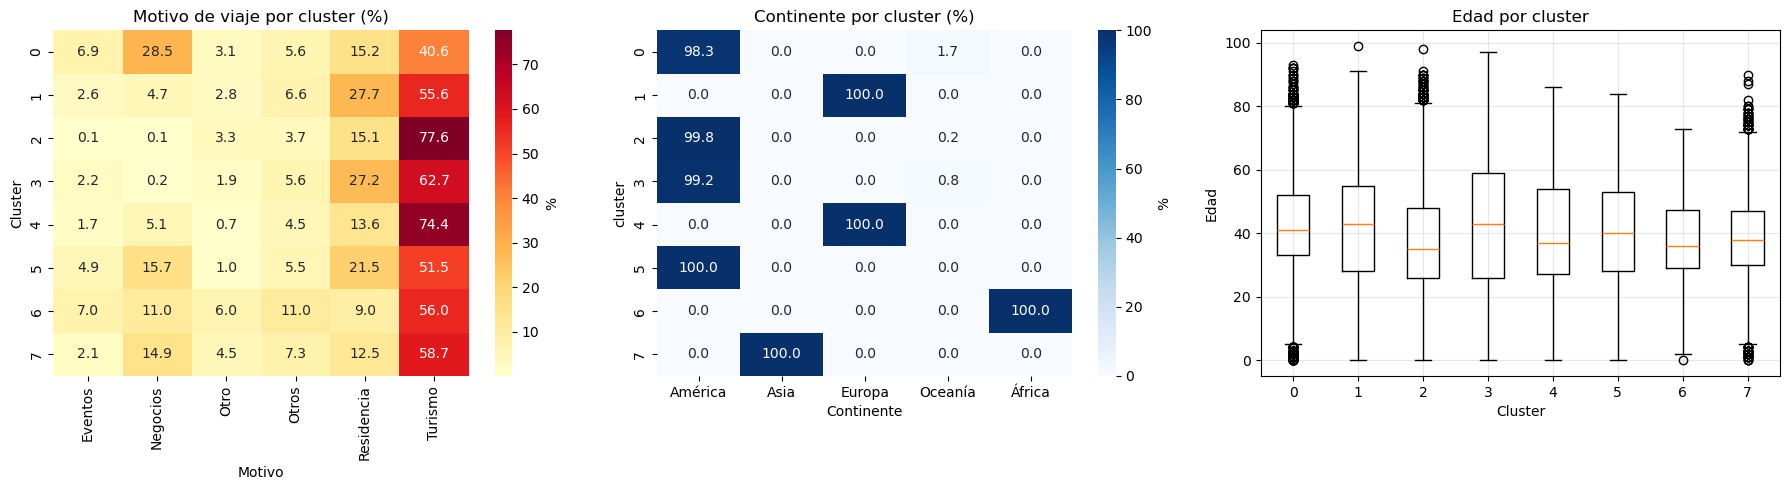

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mot_pivot = pd.crosstab(df_clean['cluster'], df_clean['mot_viam_grp'], normalize='index')*100
sns.heatmap(mot_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label':'%'})
axes[0].set_title('Motivo de viaje por cluster (%)'); axes[0].set_ylabel('Cluster'); axes[0].set_xlabel('Motivo')
cont_pivot = pd.crosstab(df_clean['cluster'], df_clean['cont_nac'], normalize='index')*100
sns.heatmap(cont_pivot, annot=True, fmt='.1f', cmap='Blues', ax=axes[1], cbar_kws={'label':'%'})
axes[1].set_title('Continente por cluster (%)'); axes[1].set_xlabel('Continente')
edad_data = [df_clean[df_clean['cluster']==c]['edad'].values for c in sorted(df_clean['cluster'].unique())]
axes[2].boxplot(edad_data, labels=sorted(df_clean['cluster'].unique()))
axes[2].set_title('Edad por cluster'); axes[2].set_xlabel('Cluster'); axes[2].set_ylabel('Edad'); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, '13_perfiles_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Evolucion de la composicion (resilientes vs colapsados)

In [13]:
dist_anio = pd.crosstab(df_clean['cluster'], df_clean['anio_etiq'], normalize='columns')*100
conteo = pd.crosstab(df_clean['cluster'], df_clean['anio_etiq'])
print('Distribucion relativa de clusters por anio (%):')
print(dist_anio.round(2))
print()
print('Conteos absolutos por anio:')
print(conteo)
var_pct = ((conteo[2024] - conteo[2023]) / conteo[2023] * 100).round(2)
print()
print('Variacion 2023->2024 (% sobre muestra):')
print(var_pct.sort_values())

Distribucion relativa de clusters por anio (%):
anio_etiq   2023   2024   2025
cluster                       
0          16.33  22.64  17.17
1          17.08  17.25  19.66
2          21.36  15.38  15.81
3          35.92  36.50  41.09
4           1.57   1.37   1.30
5           1.90   2.23   1.89
6           0.22   0.14   0.14
7           5.62   4.49   2.93

Conteos absolutos por anio:
anio_etiq   2023   2024   2025
cluster                       
0           7232   9409   5346
1           7566   7168   6122
2           9458   6392   4924
3          15907  15167  12795
4            697    569    406
5            842    925    590
6             98     59     43
7           2488   1865    911

Variacion 2023->2024 (% sobre muestra):
cluster
6   -39.80
2   -32.42
7   -25.04
4   -18.36
1    -5.26
3    -4.65
5     9.86
0    30.10
dtype: float64


In [14]:
df_clean['periodo'] = np.where((df_clean['anio_etiq']==2023) & (df_clean['mes_num']<=6), '2023_H1',
                       np.where((df_clean['anio_etiq']==2024) & (df_clean['mes_num']>=7), '2024_H2', 'otro'))
comp = df_clean[df_clean['periodo']!='otro']
abs_per = pd.crosstab(comp['cluster'], comp['periodo'])
print('Absolutos por periodo:')
print(abs_per)
var_periodo = ((abs_per['2024_H2'] - abs_per['2023_H1']) / abs_per['2023_H1'] * 100).round(2)
print()
print('Variacion 2023_H1 -> 2024_H2 (%):')
print(var_periodo.sort_values())

Absolutos por periodo:
periodo  2023_H1  2024_H2
cluster                  
0           3574     4810
1           3633     3937
2           5266     3627
3           8044     7736
4            310      321
5            405      508
6             51       28
7           1184      676

Variacion 2023_H1 -> 2024_H2 (%):
cluster
6   -45.10
7   -42.91
2   -31.12
3    -3.83
4     3.55
1     8.37
5    25.43
0    34.58
dtype: float64


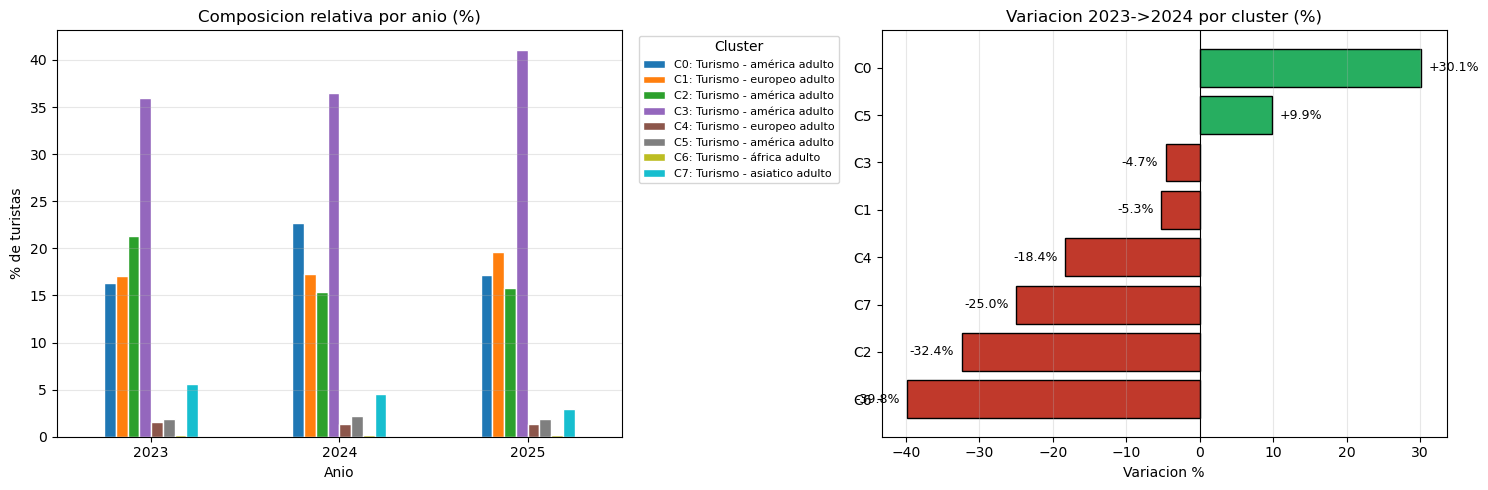

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
etiquetas = [f"C{c}: {n[:35]}" for c, n in zip(perfil_df['cluster'], perfil_df['nombre'])]
dist_anio.T.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Composicion relativa por anio (%)')
axes[0].set_xlabel('Anio'); axes[0].set_ylabel('% de turistas')
axes[0].legend(etiquetas, title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0); axes[0].grid(alpha=0.3, axis='y')
var_sorted = var_pct.sort_values()
colors = ['#c0392b' if v<0 else '#27ae60' for v in var_sorted.values]
bars = axes[1].barh([f'C{c}' for c in var_sorted.index], var_sorted.values, color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Variacion 2023->2024 por cluster (%)')
axes[1].set_xlabel('Variacion %')
for bar, v in zip(bars, var_sorted.values):
    axes[1].text(v + (1 if v>=0 else -1), bar.get_y()+bar.get_height()/2,
                 f'{v:+.1f}%', va='center', ha='left' if v>=0 else 'right', fontsize=9)
axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, '14_evolucion_segmentos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print('=' * 70)
print('RESUMEN ANALISIS 4 - K-Means perfiles turistas (ESI 2023-2025)')
print('=' * 70)
print(f'Muestra: {len(df_clean):,} registros | k optimo={k_opt} | Silhouette={sil_opt:.4f}')
if sil_opt < 0.5:
    print('(Silhouette < 0.5: solapamiento esperable con features one-hot)')
print()
for _, r in perfil_df.iterrows():
    print(f"C{r['cluster']}: {r['nombre']} ({r['pct']:.1f}%, edad media {r['edad_media']:.1f})")
    print(f"     Nacionalidades: {r['top5_nacionalidades']}")
print()
print('Variacion 2023->2024:')
for c, v in var_pct.sort_values().items():
    nombre = perfil_df.set_index('cluster').loc[c, 'nombre']
    print(f'   C{c} ({nombre}): {v:+.2f}%')
print()
colapsado = var_pct.idxmin(); resiliente = var_pct.idxmax()
n_col = perfil_df.set_index('cluster').loc[colapsado, 'nombre']
n_res = perfil_df.set_index('cluster').loc[resiliente, 'nombre']
print(f'COLAPSADO:  C{colapsado} ({n_col}) {var_pct[colapsado]:+.2f}%')
print(f'RESILIENTE: C{resiliente} ({n_res}) {var_pct[resiliente]:+.2f}%')
print()
print('Archivos en outputs/:')
for f in ['12_codo_silhouette.png','13_perfiles_clusters.png','14_evolucion_segmentos.png','tabla_clusters_caracterizacion.csv']:
    print('  -', f)

RESUMEN ANALISIS 4 - K-Means perfiles turistas (ESI 2023-2025)
Muestra: 116,979 registros | k optimo=8 | Silhouette=0.2108
(Silhouette < 0.5: solapamiento esperable con features one-hot)

C0: Turismo - américa adulto (18.8%, edad media 42.1)
     Nacionalidades: Colombia, Otro, México, Perú, Argentina
C1: Turismo - europeo adulto (17.8%, edad media 41.5)
     Nacionalidades: España, Otro, Alemania, Reino Unido, Italia
C2: Turismo - américa adulto (17.8%, edad media 36.9)
     Nacionalidades: Colombia, Perú, Venezuela, Otro, Estados Unidos de América
C3: Turismo - américa adulto (37.5%, edad media 42.4)
     Nacionalidades: Estados Unidos de América, Colombia, Otro, Canadá, Perú
C4: Turismo - europeo adulto (1.4%, edad media 39.7)
     Nacionalidades: Francia
C5: Turismo - américa adulto (2.0%, edad media 39.3)
     Nacionalidades: Chile
C6: Turismo - áfrica adulto (0.2%, edad media 38.2)
     Nacionalidades: Otro
C7: Turismo - asiatico adulto (4.5%, edad media 38.7)
     Nacionalidades